# Project Progress Report - From Failed Attempts to Final Hybrid Auto Mode

This notebook documents the full progression of the coin-recognition project, including **wrong steps**, their concrete visual results, and why we moved to the final strategy for both **count** and **value** estimation.

Main goals:
- show what failed and why,
- show evidence on difficult backgrounds (group 3 and group 5),
- show the false-positive failure on a simple image when Hough was tuned aggressively,
- explain why we tried watershed, then hybrid combination,
- explain why we introduced easy/medium/difficult scene labeling with auto mode.


## Contents

1. Setup and dataset context
2. Utility functions and experiment helpers
3. Evidence table and automatic case selection
4. Attempt A/B (threshold + contour) and why they failed
5. Hough baseline and the wrong aggressive tuning step
6. Why watershed was introduced
7. Why we combined methods (hough + watershed)
8. Easy/medium/difficult labeling and auto routing
9. Count + value evaluation snapshot
10. Final timeline and conclusions


In [22]:
# Setup imports and robust project-root detection
from pathlib import Path
import os
import sys
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _find_project_root(start: Path) -> Path:
    start = start.resolve()
    for base in [start, *start.parents]:
        if (base / "src").exists() and (base / "src_v2").exists():
            return base
        candidate = base / "Image_projet_money"
        if (candidate / "src").exists() and (candidate / "src_v2").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and src_v2/.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import cv2

from src.config import RuntimeConfig
from src.dataset import DatasetRepository
from src.io_utils import ImagePathResolver
from src.processor import CoinProcessor

from src_v2.config import HoughSettings, ContourSettings, WatershedSettings, PolicySettings
from src_v2.preprocessing import resize_if_needed, prepare_gray, build_edge_map, build_binary_mask
from src_v2.detectors import (
    detect_hough_circles,
    detect_contour_circles,
    detect_watershed_circles,
    merge_circle_sets,
    draw_overlay,
)
from src_v2.policy import classify_background
from src_v2.analyzer import HybridCoinAnalyzer

# Shared runtime objects
df_gt = DatasetRepository().to_dataframe()
resolver = ImagePathResolver(RuntimeConfig().IMAGE_DIRECTORY)

hough_default = HoughSettings()
# Aggressive profile we tried to recover hard scenes; this produced many false positives on easy scenes.
hough_aggressive = replace(
    hough_default,
    dp=max(0.9, hough_default.dp * 0.95),
    min_dist=max(12, int(round(hough_default.min_dist * 0.62))),
    param2=max(12, int(round(hough_default.param2 * 0.58))),
    min_radius=max(6, int(round(hough_default.min_radius * 0.8))),
)
contour_cfg = ContourSettings()
watershed_cfg = WatershedSettings()
policy_cfg = PolicySettings()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CWD:", Path.cwd())
print("Annotated rows:", len(df_gt))
print("Hough default:", hough_default)
print("Hough aggressive:", hough_aggressive)


PROJECT_ROOT: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money
CWD: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money
Annotated rows: 107
Hough default: HoughSettings(dp=1.2, min_dist=57, param1=120, param2=38, min_radius=10, max_radius=160)
Hough aggressive: HoughSettings(dp=1.14, min_dist=35, param1=120, param2=22, min_radius=8, max_radius=160)


## 1) Dataset Context

We first inspect how many labeled images we have per group before running progression experiments.


In [23]:
df_preview = df_gt.copy()
df_preview["group_norm"] = df_preview["group"].str.lower().str.replace("grp", "gp", regex=False)

group_stats = (
    df_preview.groupby("group_norm")
    .agg(images=("image", "count"), avg_pieces=("pieces", "mean"), value_labels=("value_eur", lambda s: int(s.notna().sum())))
    .reset_index()
    .sort_values("group_norm")
)

display(group_stats)
print("Rows with value labels:", int(df_preview["value_eur"].notna().sum()))


,group_norm,images,avg_pieces,value_labels
0,gp1,15,6.066667,15
1,gp2,15,5.733333,14
2,gp3,10,19.200000,10
3,gp4,10,6.000000,10
4,gp5,25,14.280000,24
5,gp6,10,10.400000,10
6,gp7,12,11.083333,12
7,gp8,10,8.800000,10


Rows with value labels: 105


## 2) Utility Functions

This block defines helpers used in the rest of the notebook:
- scene loading + preprocessing,
- early attempt implementations,
- visualization helpers,
- metric helpers.


In [24]:
def normalize_group(text: str) -> str:
    t = str(text).strip().lower()
    if t.startswith("grp"):
        return "gp" + t[3:]
    return t


def to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def border_cv(gray: np.ndarray) -> float:
    h, w = gray.shape[:2]
    border = max(4, int(round(min(h, w) * 0.08)))
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[:border, :] = 1
    mask[-border:, :] = 1
    mask[:, :border] = 1
    mask[:, -border:] = 1

    values = gray[mask > 0].astype(np.float32)
    if values.size == 0:
        values = gray.astype(np.float32).reshape(-1)

    mean_val = float(np.mean(values))
    if mean_val <= 1e-6:
        return 0.0
    return float(np.std(values) / mean_val)


def resolve_row_path(row: pd.Series) -> str | None:
    return resolver.resolve(str(row["image"]), str(row["group"]))


def load_scene(row: pd.Series):
    path = resolve_row_path(row)
    if not path:
        return None

    img = cv2.imread(path)
    if img is None:
        return None

    img_r = resize_if_needed(img, int(policy_cfg.target_width))
    gray = prepare_gray(img_r)
    edges = build_edge_map(gray, threshold1=60, threshold2=150)
    binary = build_binary_mask(gray, contour_cfg)

    bcv = border_cv(gray)
    ed = float(cv2.countNonZero(edges) / max(1, edges.size))
    bg_label, texture_score = classify_background(bcv, ed, policy_cfg)

    return {
        "image": str(row["image"]),
        "group_raw": str(row["group"]),
        "group_norm": normalize_group(row["group"]),
        "true_count": int(row["pieces"]),
        "true_value": float(row["value_eur"]) if pd.notna(row["value_eur"]) else np.nan,
        "path": path,
        "img": img_r,
        "gray": gray,
        "edges": edges,
        "binary": binary,
        "border_cv": bcv,
        "edge_density": ed,
        "texture_score": texture_score,
        "bg_label": bg_label,
    }


def attempt_a_otsu_components(img_bgr: np.ndarray, min_area: int = 250):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, bw = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    candidates = []
    for polarity, cand in [("normal", bw), ("inverted", cv2.bitwise_not(bw))]:
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cand)
        area = stats[:, cv2.CC_STAT_AREA]
        valid = int(np.sum(area[1:] >= min_area))
        candidates.append((valid, polarity, cand))

    candidates.sort(key=lambda x: x[0], reverse=True)
    count, polarity, mask = candidates[0]
    return count, polarity, mask


def attempt_b_canny_contours(
    img_bgr: np.ndarray,
    min_radius: int = 8,
    max_radius: int = 200,
    min_circularity: float = 0.65,
):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    eq = cv2.equalizeHist(gray)
    edges = cv2.Canny(eq, 45, 130)

    contours_info = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    circles = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perim = cv2.arcLength(contour, True)
        if perim <= 1e-6:
            continue

        circularity = (4.0 * np.pi * area) / (perim * perim)
        (x, y), r = cv2.minEnclosingCircle(contour)
        if r < min_radius or r > max_radius:
            continue
        if circularity < min_circularity:
            continue
        circles.append((int(round(x)), int(round(y)), int(round(r))))

    return circles, edges


def draw_legacy_overlay(img_bgr: np.ndarray, circles, label: str) -> np.ndarray:
    out = img_bgr.copy()
    for i, (x, y, r) in enumerate(circles, start=1):
        cv2.circle(out, (x, y), r, (0, 255, 255), 2)
        cv2.circle(out, (x, y), 2, (0, 0, 255), -1)
        cv2.putText(out, str(i), (x + 3, y - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(out, f"{label} | coins: {len(circles)}", (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2, cv2.LINE_AA)
    return out


def show_case_row(axes_row, title_prefix: str, scene: dict, default_circles, aggressive_circles):
    axes_row[0].imshow(to_rgb(scene["img"]))
    axes_row[0].set_title(f"{title_prefix}\nOriginal")
    axes_row[0].axis("off")

    ov_default = draw_overlay(scene["img"], default_circles, "hough-default")
    axes_row[1].imshow(to_rgb(ov_default))
    axes_row[1].set_title(f"default={len(default_circles)} | true={scene['true_count']}")
    axes_row[1].axis("off")

    ov_aggr = draw_overlay(scene["img"], aggressive_circles, "hough-aggressive")
    axes_row[2].imshow(to_rgb(ov_aggr))
    axes_row[2].set_title(f"aggressive={len(aggressive_circles)} | true={scene['true_count']}")
    axes_row[2].axis("off")


def mode_metrics(df: pd.DataFrame) -> dict:
    if df.empty:
        return {"images": 0}

    metrics = {
        "images": int(len(df)),
        "count_accuracy_%": float((df["count_diff"] == 0).mean() * 100.0),
        "count_mae": float(df["count_diff"].abs().mean()),
        "count_bias": float(df["count_diff"].mean()),
    }

    value_mask = df["value_diff"].notna()
    if value_mask.any():
        metrics["value_mae_eur"] = float(df.loc[value_mask, "value_diff"].abs().mean())
    return metrics


## 3) Build Evidence Table and Fix Demonstration Cases

We scan the dataset and compute counts for:
- Hough default,
- aggressive Hough (the failed tuning step),
- watershed,
- hybrid merge (hough + watershed).

To make the failure **explicit every run**, we pin demonstration cases to:
- hard case 1: `gp5/11.jpg`,
- hard case 2: `grp3/3_5.jpg`,
- simple false-positive case: `gp8/IMG_1137.png`.

If one of these files is unavailable, the notebook falls back to top-ranked evidence rows.


In [25]:
evidence_rows = []
for _, row in df_gt.iterrows():
    scene = load_scene(row)
    if scene is None:
        continue

    hough_circles = detect_hough_circles(scene["gray"], hough_default)
    aggressive_circles = detect_hough_circles(scene["gray"], hough_aggressive)
    ws_circles, _ = detect_watershed_circles(scene["img"], scene["binary"], watershed_cfg, contour_cfg)
    hybrid_circles = merge_circle_sets(ws_circles, hough_circles)

    true_count = scene["true_count"]
    evidence_rows.append(
        {
            "group_raw": scene["group_raw"],
            "group_norm": scene["group_norm"],
            "image": scene["image"],
            "path": scene["path"],
            "true_count": true_count,
            "true_value": scene["true_value"],
            "bg_label": scene["bg_label"],
            "texture_score": scene["texture_score"],
            "base_count": len(hough_circles),
            "aggr_count": len(aggressive_circles),
            "ws_count": len(ws_circles),
            "hy_count": len(hybrid_circles),
            "base_err": abs(len(hough_circles) - true_count),
            "aggr_err": abs(len(aggressive_circles) - true_count),
            "ws_err": abs(len(ws_circles) - true_count),
            "hy_err": abs(len(hybrid_circles) - true_count),
            "aggr_over_true": len(aggressive_circles) - true_count,
            "aggr_minus_base": len(aggressive_circles) - len(hough_circles),
            "aggr_delta_err": abs(len(aggressive_circles) - true_count) - abs(len(hough_circles) - true_count),
        }
    )

evidence_df = pd.DataFrame(evidence_rows)
print("Evidence rows:", len(evidence_df))
print("Background labels:")
print(evidence_df["bg_label"].value_counts())

hard_mask = evidence_df["group_norm"].isin(["gp3", "gp5"])
hard_improved = evidence_df[hard_mask & (evidence_df["aggr_err"] < evidence_df["base_err"])].copy()
if hard_improved.empty:
    hard_improved = evidence_df[hard_mask].copy()

simple_pool = evidence_df[evidence_df["bg_label"] == "easy"].copy()
if simple_pool.empty:
    simple_pool = evidence_df.copy()

hybrid_pool = evidence_df[hard_mask & (evidence_df["hy_err"] < evidence_df["base_err"])].copy()
if hybrid_pool.empty:
    hybrid_pool = evidence_df[hard_mask].copy()

print("\nTop easy-scene aggressive false positives:")
display(
    simple_pool.sort_values(["aggr_over_true", "aggr_minus_base"], ascending=[False, False]).head(8)[
        [
            "group_raw",
            "image",
            "bg_label",
            "true_count",
            "base_count",
            "aggr_count",
            "aggr_over_true",
            "base_err",
            "aggr_err",
        ]
    ]
)

print("Top gp3/gp5 rows where aggressive tuning reduced error:")
display(
    hard_improved.sort_values(["aggr_delta_err", "aggr_err", "base_err"]).head(8)[
        [
            "group_raw",
            "image",
            "bg_label",
            "true_count",
            "base_count",
            "aggr_count",
            "base_err",
            "aggr_err",
            "aggr_delta_err",
        ]
    ]
)

available = {(str(r.group_raw), str(r.image)) for r in evidence_df.itertuples()}

PREFERRED_HARD_KEYS = [("gp5", "11.jpg"), ("grp3", "3_5.jpg")]
PREFERRED_SIMPLE_FP_KEY = ("gp8", "IMG_1137.png")
PREFERRED_HYBRID_KEY = ("grp3", "3_5.jpg")


def choose_hard_keys():
    chosen = []
    for key in PREFERRED_HARD_KEYS:
        if key in available and key not in chosen:
            chosen.append(key)

    if len(chosen) < 2:
        fallback = hard_improved.sort_values(["aggr_delta_err", "base_err", "true_count"], ascending=[True, False, False])
        for r in fallback.itertuples():
            key = (str(r.group_raw), str(r.image))
            if key in chosen:
                continue
            chosen.append(key)
            if len(chosen) == 2:
                break
    return chosen[:2]


def choose_simple_fp_key():
    if PREFERRED_SIMPLE_FP_KEY in available:
        return PREFERRED_SIMPLE_FP_KEY
    row = simple_pool.sort_values(["aggr_over_true", "aggr_minus_base"], ascending=[False, False]).iloc[0]
    return (str(row["group_raw"]), str(row["image"]))


def choose_hybrid_key():
    if PREFERRED_HYBRID_KEY in available:
        return PREFERRED_HYBRID_KEY
    row = hybrid_pool.sort_values(["hy_err", "base_err", "true_count"], ascending=[True, False, False]).iloc[0]
    return (str(row["group_raw"]), str(row["image"]))


HARD_CASE_KEYS = choose_hard_keys()
SIMPLE_FP_KEY = choose_simple_fp_key()
HYBRID_CASE_KEY = choose_hybrid_key()

selected_keys = HARD_CASE_KEYS + [SIMPLE_FP_KEY, HYBRID_CASE_KEY]
selected_df = (
    evidence_df[
        evidence_df.apply(lambda r: (str(r["group_raw"]), str(r["image"])) in set(selected_keys), axis=1)
    ]
    .drop_duplicates(["group_raw", "image"])
    .sort_values(["group_norm", "image"])
)

display(
    selected_df[
        [
            "group_raw",
            "image",
            "bg_label",
            "true_count",
            "base_count",
            "aggr_count",
            "ws_count",
            "hy_count",
            "base_err",
            "aggr_err",
            "ws_err",
            "hy_err",
        ]
    ]
)

print("HARD_CASE_KEYS:", HARD_CASE_KEYS)
print("SIMPLE_FP_KEY:", SIMPLE_FP_KEY)
print("HYBRID_CASE_KEY:", HYBRID_CASE_KEY)

if SIMPLE_FP_KEY in {(str(r.group_raw), str(r.image)) for r in evidence_df.itertuples()}:
    fp_row = evidence_df[(evidence_df["group_raw"] == SIMPLE_FP_KEY[0]) & (evidence_df["image"] == SIMPLE_FP_KEY[1])].iloc[0]
    print(
        "Simple FP case summary:",
        f"true={int(fp_row.true_count)} | default={int(fp_row.base_count)} | aggressive={int(fp_row.aggr_count)}"
    )


Evidence rows: 105
Background labels:
bg_label
easy         80
medium       24
difficult     1
Name: count, dtype: int64

Top easy-scene aggressive false positives:


,group_raw,image,bg_label,true_count,base_count,aggr_count,aggr_over_true,base_err,aggr_err
81,gp8,IMG_1137.png,easy,10,10,21,11,0,11
99,gp2,10.jpeg,easy,6,6,17,11,0,11
94,gp2,5.jpeg,easy,3,3,9,6,0,6
43,grp5,20.jpg,easy,12,12,15,3,0,3
47,grp5,24.jpg,easy,26,26,29,3,0,3
104,gp2,15.jpeg,easy,5,3,7,2,2,2
100,gp2,11.jpeg,easy,9,8,11,2,1,2
59,gp6,61.jpg,easy,11,11,13,2,0,2


Top gp3/gp5 rows where aggressive tuning reduced error:


,group_raw,image,bg_label,true_count,base_count,aggr_count,base_err,aggr_err,aggr_delta_err
1,gp5,11.jpg,medium,12,7,10,5,2,-3
35,grp3,3_5.jpg,medium,25,20,23,5,2,-3
14,gp5,6.jpeg,easy,11,9,11,2,0,-2
40,grp3,3_10.jpg,medium,35,33,35,2,0,-2
11,gp5,3.jpeg,easy,4,3,4,1,0,-1
13,gp5,5.jpeg,easy,2,1,2,1,0,-1
34,grp3,3_4.jpg,easy,10,9,10,1,0,-1
46,grp5,23.jpg,easy,20,19,20,1,0,-1


,group_raw,image,bg_label,true_count,base_count,aggr_count,ws_count,hy_count,base_err,aggr_err,ws_err,hy_err
35,grp3,3_5.jpg,medium,25,20,23,20,23,5,2,5,2
1,gp5,11.jpg,medium,12,7,10,1,8,5,2,11,4
81,gp8,IMG_1137.png,easy,10,10,21,2,11,0,11,8,1


HARD_CASE_KEYS: [('gp5', '11.jpg'), ('grp3', '3_5.jpg')]
SIMPLE_FP_KEY: ('gp8', 'IMG_1137.png')
HYBRID_CASE_KEY: ('grp3', '3_5.jpg')
Simple FP case summary: true=10 | default=10 | aggressive=21


## 4) Attempt A/B - Wrong Steps and Results

### Attempt A: Otsu threshold + connected components
- Idea: segment foreground and count blobs.
- Failure mode: background texture and coin touching merge/split components.

### Attempt B: Canny + contour circularity
- Idea: keep contours that look circular.
- Failure mode: edge fragmentation, partial contours, and unstable contour geometry on textured scenes.

Below we show one difficult-background case with visual evidence.


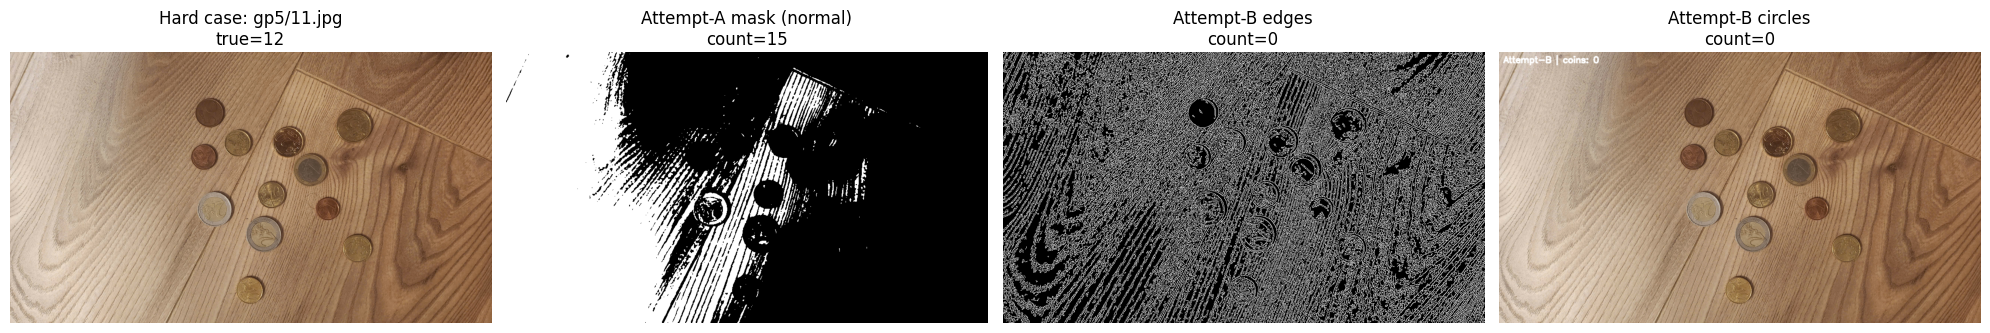

,case,true,attempt_A_count,attempt_B_count,hough_default_count,A_abs_err,B_abs_err
0,gp5/11.jpg,12,15,0,7,3,12
1,gp3/3_5.jpg,25,24,0,20,1,25
2,gp8/IMG_1137.png,10,20,2,10,10,8


In [26]:
def find_row(group_raw: str, image: str) -> pd.Series:
    sub = df_gt[(df_gt["group"] == group_raw) & (df_gt["image"] == image)]
    if sub.empty:
        raise ValueError(f"Row not found: {group_raw}/{image}")
    return sub.iloc[0]


hard_scene = load_scene(find_row(*HARD_CASE_KEYS[0]))
a_count, a_polarity, a_mask = attempt_a_otsu_components(hard_scene["img"])
b_circles, b_edges = attempt_b_canny_contours(hard_scene["img"])
b_overlay = draw_legacy_overlay(hard_scene["img"], b_circles, "Attempt-B")
base_circles = detect_hough_circles(hard_scene["gray"], hough_default)
base_overlay = draw_overlay(hard_scene["img"], base_circles, "hough-default")

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[0].imshow(to_rgb(hard_scene["img"]))
axes[0].set_title(f"Hard case: {hard_scene['group_norm']}/{hard_scene['image']}\ntrue={hard_scene['true_count']}")
axes[0].axis("off")

axes[1].imshow(a_mask, cmap="gray")
axes[1].set_title(f"Attempt-A mask ({a_polarity})\ncount={a_count}")
axes[1].axis("off")

axes[2].imshow(b_edges, cmap="gray")
axes[2].set_title(f"Attempt-B edges\ncount={len(b_circles)}")
axes[2].axis("off")

axes[3].imshow(to_rgb(b_overlay))
axes[3].set_title(f"Attempt-B circles\ncount={len(b_circles)}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

ab_rows = []
case_keys = list(dict.fromkeys(HARD_CASE_KEYS + [SIMPLE_FP_KEY]))
for g, im in case_keys:
    scene = load_scene(find_row(g, im))
    a_cnt, _, _ = attempt_a_otsu_components(scene["img"])
    b_cc, _ = attempt_b_canny_contours(scene["img"])
    base_cc = detect_hough_circles(scene["gray"], hough_default)
    ab_rows.append(
        {
            "case": f"{scene['group_norm']}/{scene['image']}",
            "true": scene["true_count"],
            "attempt_A_count": a_cnt,
            "attempt_B_count": len(b_cc),
            "hough_default_count": len(base_cc),
            "A_abs_err": abs(a_cnt - scene["true_count"]),
            "B_abs_err": abs(len(b_cc) - scene["true_count"]),
        }
    )

display(pd.DataFrame(ab_rows))


## 5) Hough Baseline and the Aggressive-Tuning Failure

We then moved to Hough circles and improved stability.

Wrong step we made:
- We tightened/aggressively tuned Hough controls to recover difficult scenes (group 3 and group 5).
- This helped some difficult images but produced **too many circles** on simple scenes (false positives / *fausse positives*).

The next panel shows exactly that tradeoff:
- row 1-2: difficult backgrounds (group 3 / group 5),
- row 3: simple scene with strong over-detection under aggressive parameters.


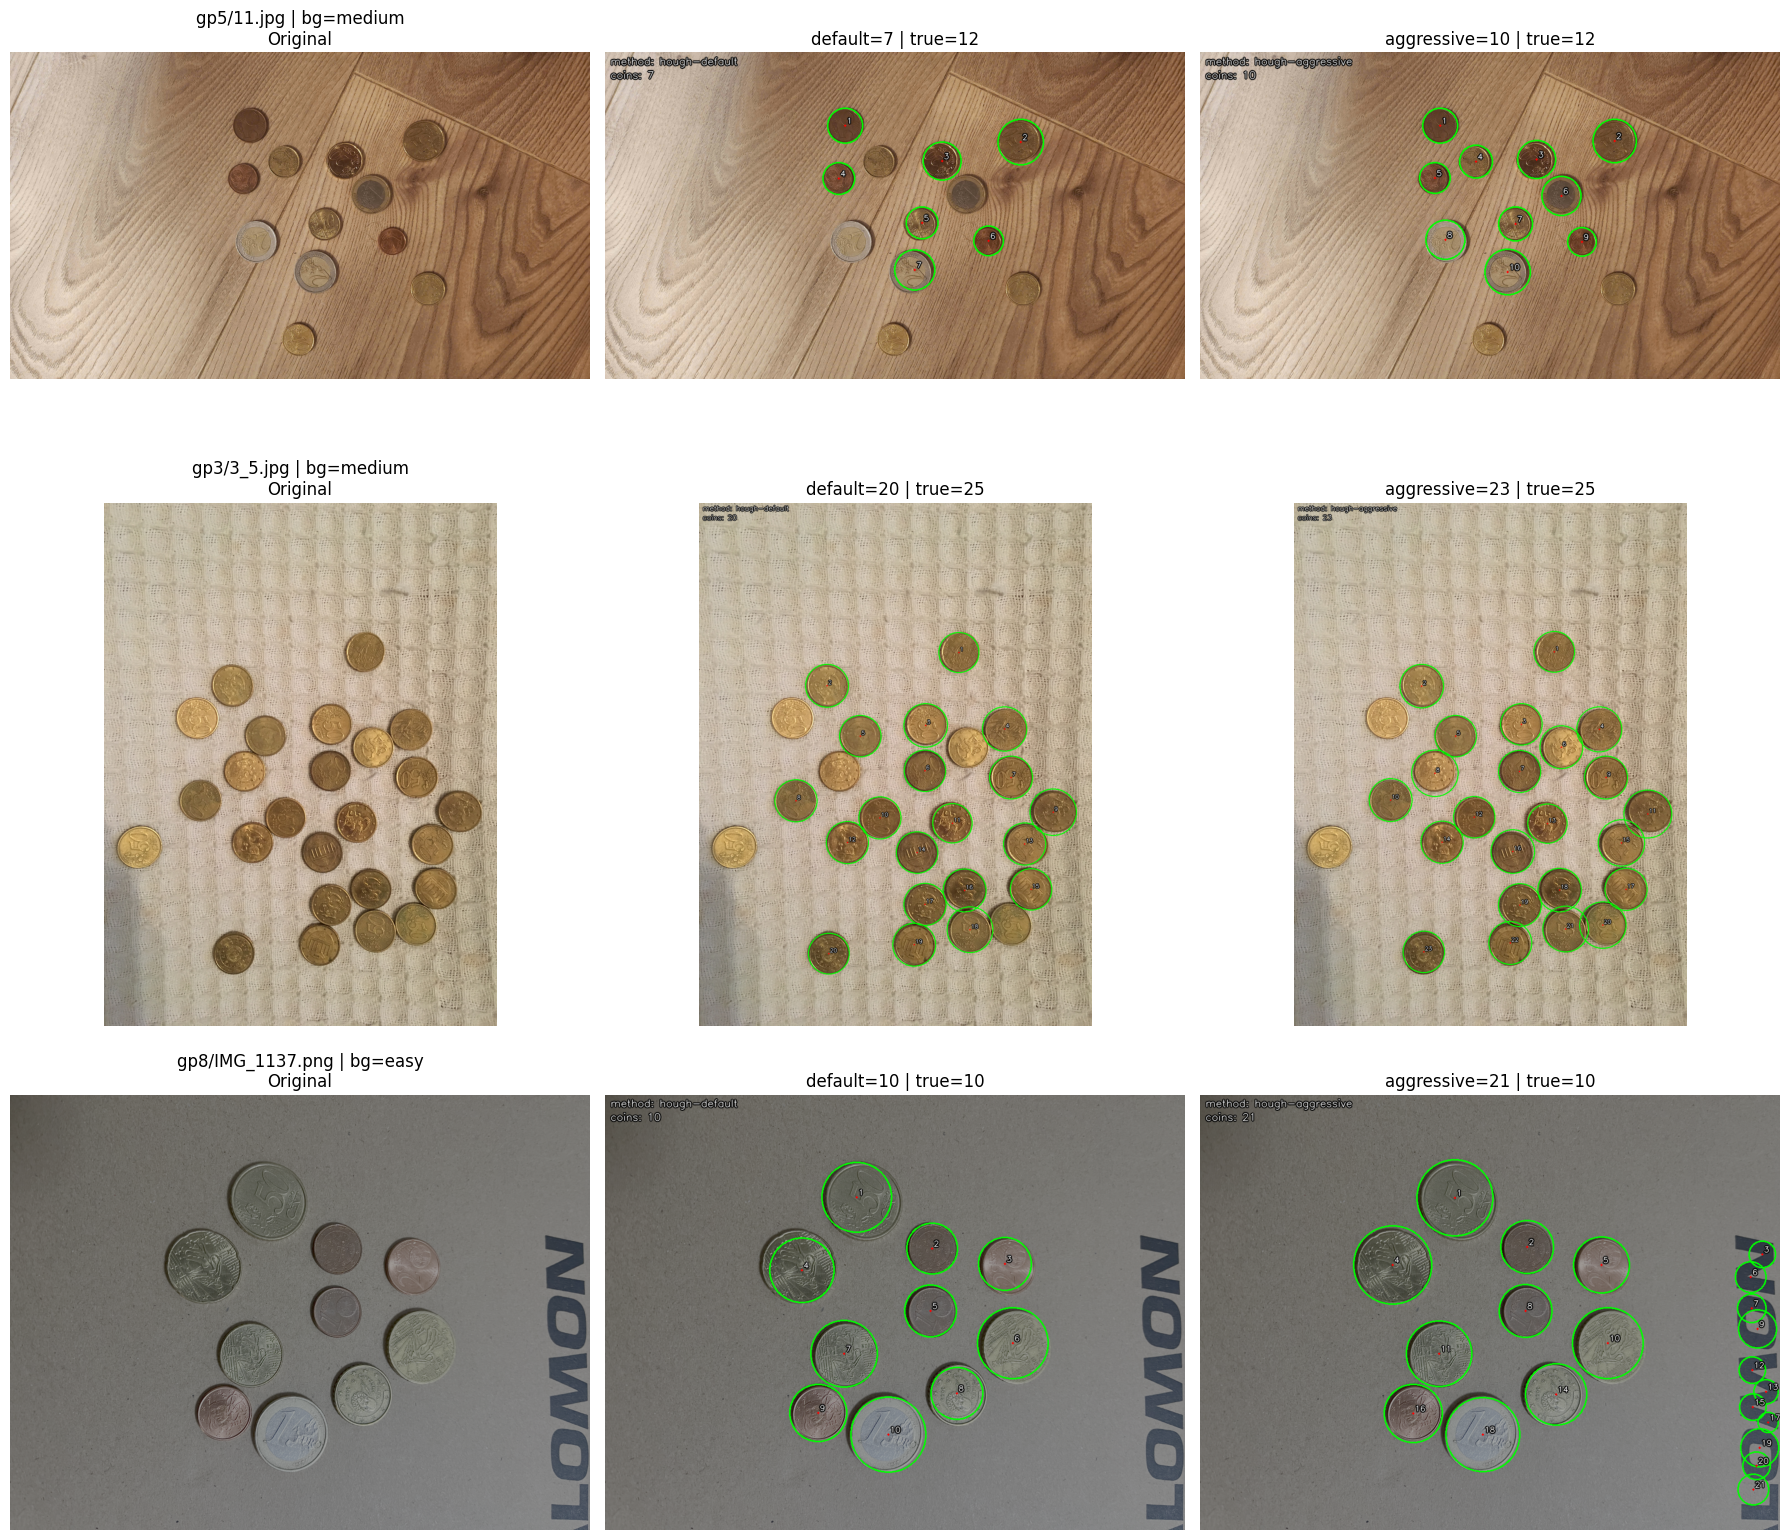

,case,background,true,hough_default,hough_aggressive,default_err,aggressive_err,aggressive_minus_true
0,gp5/11.jpg,medium,12,7,10,5,2,-2
1,gp3/3_5.jpg,medium,25,20,23,5,2,-2
2,gp8/IMG_1137.png,easy,10,10,21,0,11,11


In [27]:
strict_keys = list(dict.fromkeys(HARD_CASE_KEYS + [SIMPLE_FP_KEY]))

fig, axes = plt.subplots(len(strict_keys), 3, figsize=(18, 5.5 * len(strict_keys)))
if len(strict_keys) == 1:
    axes = np.expand_dims(axes, axis=0)

strict_rows = []
for i, (g, im) in enumerate(strict_keys):
    scene = load_scene(find_row(g, im))
    base_circles = detect_hough_circles(scene["gray"], hough_default)
    aggr_circles = detect_hough_circles(scene["gray"], hough_aggressive)

    title_prefix = f"{scene['group_norm']}/{scene['image']} | bg={scene['bg_label']}"
    show_case_row(axes[i], title_prefix, scene, base_circles, aggr_circles)

    strict_rows.append(
        {
            "case": f"{scene['group_norm']}/{scene['image']}",
            "background": scene["bg_label"],
            "true": scene["true_count"],
            "hough_default": len(base_circles),
            "hough_aggressive": len(aggr_circles),
            "default_err": abs(len(base_circles) - scene["true_count"]),
            "aggressive_err": abs(len(aggr_circles) - scene["true_count"]),
            "aggressive_minus_true": len(aggr_circles) - scene["true_count"],
        }
    )

plt.tight_layout()
plt.show()

strict_df = pd.DataFrame(strict_rows)
display(strict_df)


## 6) Why We Introduced Watershed

Reasoning:
- Difficult scenes often include touching clusters and complex foreground blobs.
- Hough can miss splits or become unstable with local texture.
- Watershed can split merged foreground into multiple regions.

But we also observed that pure watershed was not always best alone; results were scene-dependent.


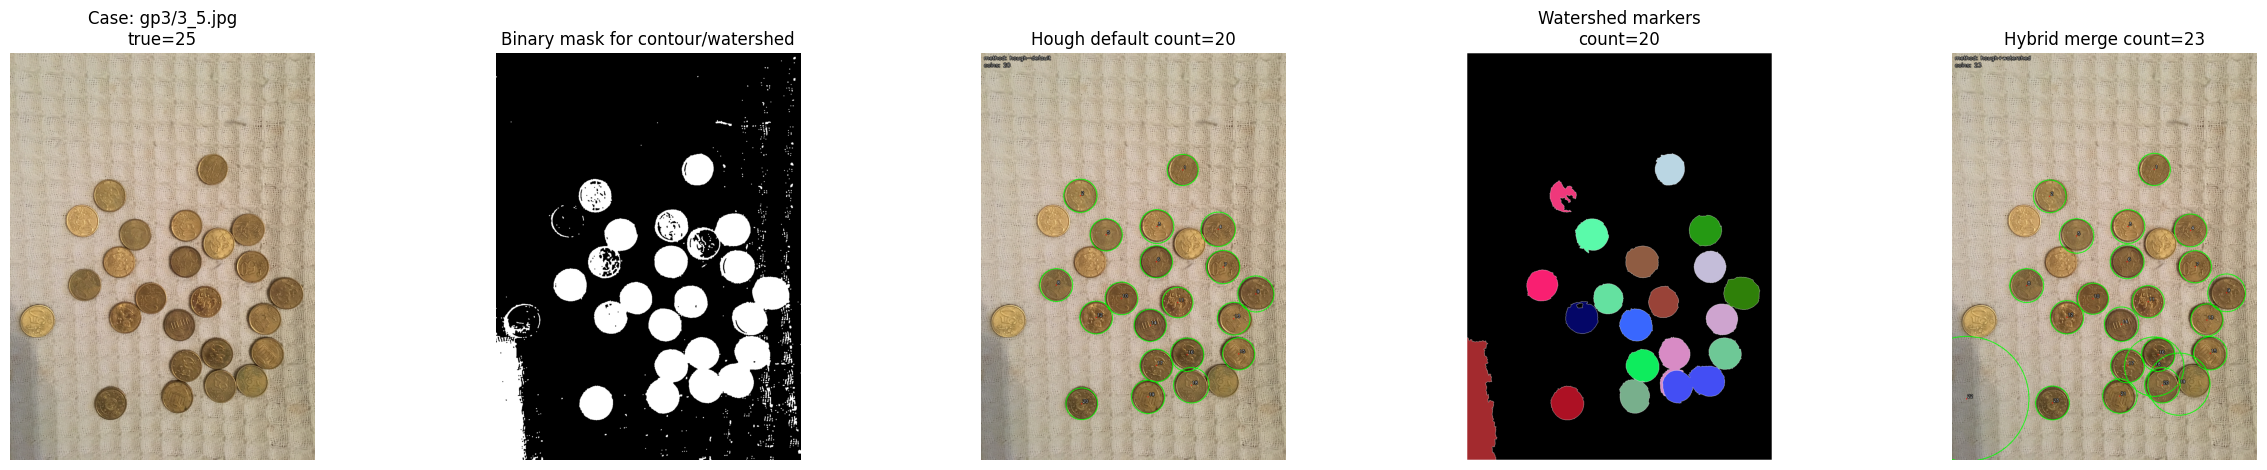

,group_norm,image,bg_label,true_count,base_count,aggr_count,ws_count,hy_count,base_err,aggr_err,ws_err,hy_err
15,gp5,8.jpg,easy,6,6,6,5,6,0,0,1,0
11,gp5,3.jpeg,easy,4,3,4,2,4,1,0,2,0
13,gp5,5.jpeg,easy,2,1,2,1,2,1,0,1,0
2,gp5,12.jpg,easy,16,16,16,1,17,0,0,15,1
32,gp3,3_2.jpg,easy,16,16,16,1,17,0,0,15,1
43,gp5,20.jpg,easy,12,12,15,9,13,0,3,3,1
42,gp5,19.jpg,easy,10,10,10,4,11,0,0,6,1
31,gp3,3_1.jpg,easy,8,8,8,5,9,0,0,3,1
33,gp3,3_3.jpg,easy,8,8,8,5,9,0,0,3,1
37,gp3,3_7.jpg,medium,8,8,9,6,9,0,1,2,1


Hard-background subset metrics: {'images': 34, 'hough_default_mae': 4.117647058823529, 'hough_aggressive_mae': 12.823529411764707, 'watershed_mae': 9.147058823529411, 'hybrid_mae': 6.0}


In [28]:
ws_scene = load_scene(find_row(*HYBRID_CASE_KEY))
base_circles = detect_hough_circles(ws_scene["gray"], hough_default)
ws_circles, ws_markers = detect_watershed_circles(ws_scene["img"], ws_scene["binary"], watershed_cfg, contour_cfg)
hy_circles = merge_circle_sets(ws_circles, base_circles)

ov_base = draw_overlay(ws_scene["img"], base_circles, "hough-default")
ov_ws = draw_overlay(ws_scene["img"], ws_circles, "watershed")
ov_hy = draw_overlay(ws_scene["img"], hy_circles, "hough+watershed")

fig, axes = plt.subplots(1, 5, figsize=(25, 4.8))
axes[0].imshow(to_rgb(ws_scene["img"]))
axes[0].set_title(f"Case: {ws_scene['group_norm']}/{ws_scene['image']}\ntrue={ws_scene['true_count']}")
axes[0].axis("off")

axes[1].imshow(ws_scene["binary"], cmap="gray")
axes[1].set_title("Binary mask for contour/watershed")
axes[1].axis("off")

axes[2].imshow(to_rgb(ov_base))
axes[2].set_title(f"Hough default count={len(base_circles)}")
axes[2].axis("off")

axes[3].imshow(ws_markers)
axes[3].set_title(f"Watershed markers\ncount={len(ws_circles)}")
axes[3].axis("off")

axes[4].imshow(to_rgb(ov_hy))
axes[4].set_title(f"Hybrid merge count={len(hy_circles)}")
axes[4].axis("off")

plt.tight_layout()
plt.show()

hard_compare = evidence_df[evidence_df["group_norm"].isin(["gp3", "gp5"])].copy()
hard_metrics = {
    "images": int(len(hard_compare)),
    "hough_default_mae": float(hard_compare["base_err"].mean()),
    "hough_aggressive_mae": float(hard_compare["aggr_err"].mean()),
    "watershed_mae": float(hard_compare["ws_err"].mean()),
    "hybrid_mae": float(hard_compare["hy_err"].mean()),
}

display(
    hard_compare[
        [
            "group_norm",
            "image",
            "bg_label",
            "true_count",
            "base_count",
            "aggr_count",
            "ws_count",
            "hy_count",
            "base_err",
            "aggr_err",
            "ws_err",
            "hy_err",
        ]
    ].sort_values(["hy_err", "base_err", "true_count"], ascending=[True, True, False]).head(14)
)
print("Hard-background subset metrics:", hard_metrics)


## 7) Why We Combined Methods

Observed behavior:
- Hough alone: strong baseline, but can miss splits in hard clutter.
- Watershed alone: can separate regions, but sometimes unstable by itself.

So we combined them (`hough + watershed`) to keep Hough's robust detections and recover extra regions from watershed when useful.


## 8) Easy/Medium/Difficult Labeling and Auto Mode

Next idea: classify scene difficulty first and route methods automatically.

Policy logic:
- estimate background complexity from border texture + edge density,
- label scene as `easy`, `medium`, or `difficult`,
- choose/adjust method in auto mode (`hough`, `hough+watershed`, etc.) per scene.


In [29]:
# Build a balanced evaluation subset across groups (up to 4 images/group)
eval_keys_df = (
    evidence_df.sort_values(["group_norm", "image"])
    .groupby("group_norm", group_keys=False)
    .head(4)
    .reset_index(drop=True)
)
print("Eval subset size:", len(eval_keys_df))


def evaluate_mode(mode: str, eval_df: pd.DataFrame):
    analyzer = HybridCoinAnalyzer()
    rows = []

    for r in eval_df.itertuples():
        img = cv2.imread(r.path)
        if img is None:
            continue
        result = analyzer.analyze(
            img,
            source_path=r.path,
            short_path=f"{r.group_norm}/{r.image}",
            mode=mode,
        )

        pred_count = int(len(result.circles))
        true_count = int(r.true_count)
        pred_value = float(result.estimated_value_eur)
        true_value = float(r.true_value) if pd.notna(r.true_value) else np.nan

        rows.append(
            {
                "mode": mode,
                "case": f"{r.group_norm}/{r.image}",
                "group": r.group_norm,
                "true_count": true_count,
                "pred_count": pred_count,
                "count_diff": pred_count - true_count,
                "background_label": result.metrics.background_label,
                "selected_method": result.selected_method,
                "pred_value": pred_value,
                "true_value": true_value,
                "value_diff": (pred_value - true_value) if pd.notna(true_value) else np.nan,
                "labeled_coin_count": int(result.labeled_coin_count),
            }
        )

    out = pd.DataFrame(rows)
    return out, mode_metrics(out)


mode_results = {}
mode_metrics_rows = []
for mode_name in ["hough", "hough+watershed", "auto"]:
    mode_df, m = evaluate_mode(mode_name, eval_keys_df)
    mode_results[mode_name] = mode_df
    m["mode"] = mode_name
    mode_metrics_rows.append(m)

mode_metrics_df = pd.DataFrame(mode_metrics_rows)
display(mode_metrics_df[["mode", "images", "count_accuracy_%", "count_mae", "count_bias", "value_mae_eur"]])

auto_df = mode_results["auto"].copy()
display(auto_df.head(16))

if not auto_df.empty:
    routing_table = pd.crosstab(auto_df["background_label"], auto_df["selected_method"])
    display(routing_table)


Eval subset size: 32


,mode,images,count_accuracy_%,count_mae,count_bias,value_mae_eur
0,hough,32,81.250,0.59375,-0.21875,1.364042
1,hough+watershed,32,59.375,1.00000,0.62500,1.580579
2,auto,32,81.250,0.59375,-0.21875,1.361651


,mode,case,group,true_count,pred_count,count_diff,background_label,selected_method,pred_value,true_value,value_diff,labeled_coin_count
0,auto,gp1/18.png,gp1,7,7,0,easy,hough,3.730242,4.31,-0.579758,7
1,auto,gp1/19.png,gp1,4,4,0,easy,hough,3.498379,1.60,1.898379,4
2,auto,gp1/20.png,gp1,8,8,0,easy,hough,4.280779,4.81,-0.529221,8
3,auto,gp1/21.png,gp1,6,6,0,easy,hough,4.115803,3.76,0.355803,6
4,auto,gp2/1.jpeg,gp2,8,8,0,medium,hough,4.698123,NaN,NaN,8
5,auto,gp2/10.jpeg,gp2,6,6,0,easy,hough,3.136800,0.96,2.176800,6
6,auto,gp2/11.jpeg,gp2,9,8,-1,easy,hough,3.403187,3.37,0.033187,8
7,auto,gp2/12.jpeg,gp2,2,1,-1,easy,hough,1.846768,3.00,-1.153232,1
8,auto,gp3/3_1.jpg,gp3,8,8,0,easy,hough,5.895548,5.00,0.895548,8
9,auto,gp3/3_10.jpg,gp3,35,30,-5,medium,hough,8.147132,3.50,4.647132,30


selected_method,hough,hough+watershed
background_label,,
easy,26,1
medium,4,1


## 9) Count and Value Progression Snapshot

The table above summarizes how the project evolved from pure count-oriented methods to full count+value prediction.

Key observation:
- Early methods (A/B) were count-only and unstable.
- Hough improved count stability.
- Watershed added splitting capability but was not consistently best alone.
- Hybrid and auto-routing improved robustness across scene types.
- Final pipeline reports both coin count and total value.


## 10) Final Timeline and Conclusions

1. **Attempt A (Otsu + components)**
   Result: brittle with textured backgrounds and touching coins.
2. **Attempt B (Canny + contour circularity)**
   Result: unstable edges/contours in real scenes.
3. **Attempt C (Hough default)**
   Result: strong jump in count reliability.
4. **Wrong step: aggressive Hough tuning for hard scenes**
   Result: helped some group 3/5 images, but generated too many circles on easy images (false positives).
5. **Watershed attempt**
   Reason: split touching regions that Hough could miss.
   Result: useful in some scenes, but not consistently best when used alone.
6. **Hybrid (hough + watershed)**
   Reason: combine robust Hough detections with watershed splits.
7. **Scene labeling + auto mode (easy / medium / difficult)**
   Reason: use one policy for all scenes was not reliable enough.
   Result: adaptive routing based on background complexity, with better overall behavior for both count and value.
